# Predicting Online News Popularity

### Big Data Analytics and Text Mining (6 CFU)

- Professor: Prof. Stefano Lodi
- Author: Safoura Banihashemi
- Academic Year: 2024–2025

## Project Overview

This project focuses on predicting Online News Popularity using four binary classification methods using PySpark.

ML algorithms:
1. Logistic Regression
2. Random Forest
3. Gradient Boosted tree
4. Support Vector Machine

## Evaluation Metrics

This project evaluates models using comprehensive performance metrics:

1. ROC Curves
2. AUC (Area Under Curve)
3. Accuracy
4. F1-Score
5. Precision
6. Recall

## Requirements

1. python 3.14.2
2. Spark 4.1.2
3. matplotlib 3.10.9
4. numpy 2.3.5
5. pandas 2.3.3
6. scikit-learn 1.9.0
7. seaborn 0.13.2

## Dataset Description

The Online News Popularity dataset contains **39,644 articles** published by Mashable between January 2013 and January 2015, with **61 features** per article.

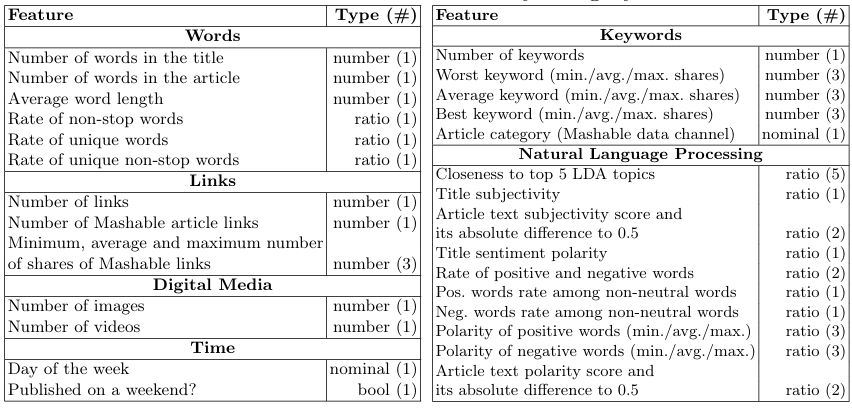

- Target: The original dataset contains a continuous count of shares. For this project, the target is engineered into two distinct classes to transform the task into a binary classification problem.

### Target Engineering

The original dataset contains a continuous count of shares (highly right-skewed). To create a balanced binary classification problem, articles are splited:

- 1 — Popular: shares > median (1,400)  
- 0 — Unpopular: shares ≤ median  

## Setting
Hardware Environment:

- System Model: Lenovo IdeaPad Slim 3 15IRH10 (83K1)
- Processor: Intel Core i7-13620H (13th Gen), 10 cores (6 P-cores + 4 E-cores), 16 threads
- RAM: 16 GB

In [134]:
import pyspark
from pyspark.sql import SparkSession

# Spark Session
spark = (
    SparkSession.builder
    .appName("OnlineNewsPopularity")
    # Run Spark locally using 12 CPU threads (cores)
    .master("local[12]")
    # 4 GB of memory to the driver process
    .config("spark.driver.memory", "4g")
    # Reduce number of shuffle partitions (default is 200)
    .config("spark.sql.shuffle.partitions", "20")
    # Increase max RPC message size
    .config("spark.rpc.message.maxSize", str(2047))
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark Version: {spark.version}")

Spark Version: 4.1.2


## Load dataset

The dataset is loaded from a local CSV file into a PySpark DataFrame.

In [135]:
import os

# Dataset path
PATH = r"D:\Github\predicting-online-news-popularity\Dataset"

# Point PySpark to the CSV file
csv_path = os.path.join(PATH, "OnlineNewsPopularity.csv")

# Load the dataset into a PySpark
sdf = spark.read.csv(csv_path, header=True, inferSchema=True)

# Verify the data loaded successfully
print(f"Total rows loaded: {sdf.count():,}")
print(f"Total features loaded: {len(sdf.columns)}")
sdf.printSchema()

Total rows loaded: 39,644
Total features loaded: 61
root
 |-- url: string (nullable = true)
 |--  timedelta: double (nullable = true)
 |--  n_tokens_title: double (nullable = true)
 |--  n_tokens_content: double (nullable = true)
 |--  n_unique_tokens: double (nullable = true)
 |--  n_non_stop_words: double (nullable = true)
 |--  n_non_stop_unique_tokens: double (nullable = true)
 |--  num_hrefs: double (nullable = true)
 |--  num_self_hrefs: double (nullable = true)
 |--  num_imgs: double (nullable = true)
 |--  num_videos: double (nullable = true)
 |--  average_token_length: double (nullable = true)
 |--  num_keywords: double (nullable = true)
 |--  data_channel_is_lifestyle: double (nullable = true)
 |--  data_channel_is_entertainment: double (nullable = true)
 |--  data_channel_is_bus: double (nullable = true)
 |--  data_channel_is_socmed: double (nullable = true)
 |--  data_channel_is_tech: double (nullable = true)
 |--  data_channel_is_world: double (nullable = true)
 |--  kw_mi

In [136]:
# Print 3 samples
sdf.show(3, truncate=True, vertical=True)

-RECORD 0----------------------------------------------
 url                            | http://mashable.c... 
  timedelta                     | 731.0                
  n_tokens_title                | 12.0                 
  n_tokens_content              | 219.0                
  n_unique_tokens               | 0.663594466988       
  n_non_stop_words              | 0.999999992308       
  n_non_stop_unique_tokens      | 0.815384609112       
  num_hrefs                     | 4.0                  
  num_self_hrefs                | 2.0                  
  num_imgs                      | 1.0                  
  num_videos                    | 0.0                  
  average_token_length          | 4.6803652968         
  num_keywords                  | 5.0                  
  data_channel_is_lifestyle     | 0.0                  
  data_channel_is_entertainment | 1.0                  
  data_channel_is_bus           | 0.0                  
  data_channel_is_socmed        | 0.0           

## Imports

In [137]:
import numpy as np
import pandas as pd
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Iterator
import math

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_curve, auc

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler, StandardScaler
import pyspark.sql.types as T
from pyspark.sql import DataFrame, Window
from pyspark.sql.functions import when, col, row_number
from dataclasses import dataclass, field
from pyspark.sql import functions as F

from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, LogisticRegression, LinearSVC, NaiveBayes
from pyspark.ml.tuning import ParamGridBuilder

from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml.tuning import TrainValidationSplit

## Exploratory Data Analysis (EDA)

Examine the distribution of the target variable (`shares`) and confirm the absence of missing values. Key findings:

- No missing values across all 61 features.
- The `shares` column is **heavily right-skewed**: most articles receive a modest number of shares while a small percentage go viral (long tail).
- The median (1,400 shares) is used as the classification threshold, producing a near-balanced binary label.

In [138]:
# Clean the columns from extra space
for col_name in sdf.columns:
    sdf = sdf.withColumnRenamed(col_name, col_name.strip())

In [139]:
# Displays every single feature's statistical summary
sdf.summary().show(vertical=True)

-RECORD 0---------------------------------------------
 summary                       | count                
 url                           | 39644                
 timedelta                     | 39644                
 n_tokens_title                | 39644                
 n_tokens_content              | 39644                
 n_unique_tokens               | 39644                
 n_non_stop_words              | 39644                
 n_non_stop_unique_tokens      | 39644                
 num_hrefs                     | 39644                
 num_self_hrefs                | 39644                
 num_imgs                      | 39644                
 num_videos                    | 39644                
 average_token_length          | 39644                
 num_keywords                  | 39644                
 data_channel_is_lifestyle     | 39644                
 data_channel_is_entertainment | 39644                
 data_channel_is_bus           | 39644                
 data_chan

In [140]:
# Separate Share's summary for better visualization
sdf.select("shares").summary().show()

+-------+------------------+
|summary|            shares|
+-------+------------------+
|  count|             39644|
|   mean|3395.3801836343455|
| stddev|11626.950748651709|
|    min|               1.0|
|    25%|             946.0|
|    50%|            1400.0|
|    75%|            2800.0|
|    max|          843300.0|
+-------+------------------+



### Key Observations from Summary Statistics:

1. There are no missing values.

2. The "shares" distribution is heavily **right-skewed** and naturally **long-tailed**.

- This shows that a typical article gets a modest number of shares, while a small percentage of articles go highly viral.

- Since the distribution is so skewed, predicting the exact number of shares is impractical. Transforming it into a binary classification problem simplifies the task into predicting Popular vs. Unpopular.

- Considering Median as threshold (1,400 shares), create an almost balanced dataset (50.66% Unpopular, 49.34% Popular).

Calculated Stats -> Mean: 3395 | Median: 1400 | Mode: 1100


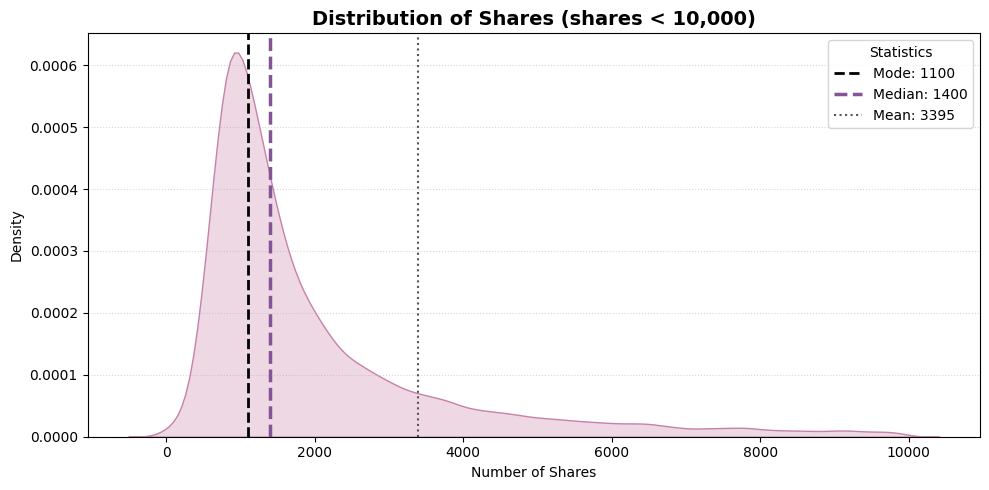

In [141]:
# "Shares" distribution visualization

# 1. Compute descriptive statistics

# Mean of shares
mean = sdf.select(F.avg("shares")).collect()[0][0]

# Median of shares using approximate percentile (efficient for big data)
# percentile_approx is preferred in Spark because the exact median is expensive
median = sdf.select(F.expr("percentile_approx(shares, 0.5)")).collect()[0][0]

# Mode of shares (Group by shares, count the frequency of them, sort descending, and take the most frequent)
mode_row = sdf.groupBy("shares").count().orderBy(F.desc("count")).first()
mode = mode_row["shares"]

# Print computed statistics
print(f"Calculated Stats -> Mean: {mean:.0f} | Median: {median:.0f} | Mode: {mode:.0f}")

# 2. Prepare data for visualization

# Filter extreme outliers to make the plot more readable (very viral articles)
filtered_pdf = sdf.filter(F.col("shares") < 10000).select("shares").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))

# Kernel Density Estimate (smooth distribution curve)
# bw_adjust controls smoothness (lower = more detailed, higher = smoother)
sns.kdeplot(filtered_pdf['shares'], color="#C781A8", fill=True, alpha=0.3, bw_adjust=0.8)

# Add statistical reference lines
# Mode line (most frequent value)
ax.axvline(mode, color='black', linestyle='--', linewidth=2, label=f'Mode: {mode:.0f}')
# Median line (50th percentile)
ax.axvline(median, color='#835496', linestyle='--', linewidth=2.5, label=f'Median: {median:.0f}')
# Mean line (sensitive to the most viral posts)
ax.axvline(mean, color='#555555', linestyle=':', linewidth=1.5, label=f'Mean: {mean:.0f}')

# Styling and labels
ax.set_title("Distribution of Shares (shares < 10,000)", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Shares")
ax.set_ylabel("Density")
# Clean white background for readability
ax.set_facecolor('white')
# Light horizontal grid for better visual guidance
ax.grid(axis='y', linestyle=':', alpha=0.5)
# Legend showing statistical markers
ax.legend(title="Statistics")
# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [142]:
""" 
Define classification threshold: 
        Create a new column "label":
            - 1 if shares > median (popular article)
            - 0 otherwise (unpopular article)
"""

# Use median shares as threshold for binary classification
THRESHOLD = int(median)
print(f"Median shares: {THRESHOLD}")

# Create binary target variable
# PySpark evaluates the condition as True/False, and .cast("integer") converts it into 1/0 format
sdf = sdf.withColumn("label", (F.col("shares") > THRESHOLD).cast("integer")) 

# Calculate the number of samples
num_sampels = sdf.count()
# Group by label (0/1) and count the number of samples for each class
counts_label = sdf.groupBy("label").count().collect()
# Convert Spark output (list of Rows) into a Python dictionary
counts = {row['label']: row['count'] for row in counts_label}

# Print class balance results
print(f"\nClass distribution:")
print(f"Popular(1): {counts.get(1, 0)} ({counts.get(1, 0)/num_samples:.2%})")
print(f"Unpopular(0): {counts.get(0, 0)} ({counts.get(0, 0)/num_samples:.2%})")

Median shares: 1400

Class distribution:
Popular(1): 19562 (49.34%)
Unpopular(0): 20082 (50.66%)


   label  count
0      0  20082
1      1  19562


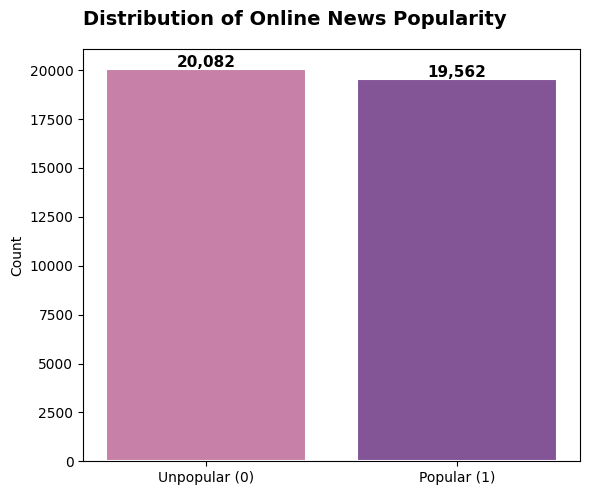

In [143]:
# Class distribution visualization

# Group by label (0/1), Count the number of occurrences in each class, Sort by label (first 0 and second 1)
counts_pdf = sdf.groupBy("label").count().orderBy("label").toPandas()
# Print the resulting dataframe to verify correctness
print(counts_pdf)

# Plot class distribution (bar chart)
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Distribution of Online News Popularity", fontsize=14, fontweight="bold")
# Create bar plot
bars = ax.bar(["Unpopular (0)", "Popular (1)"], counts_pdf["count"], color=["#C781A8", "#835496"], edgecolor="white", linewidth=1.5)
# Annotate each bar with its exact count value
for bar, v in zip(bars, counts_pdf["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
# Label for Y-axis
ax.set_ylabel("Count")
# Adjust layout to avoid overlap of elements
plt.tight_layout()
plt.show()

In [144]:
# Print 3 samples
sdf.show(3, truncate=True, vertical=True)

-RECORD 0---------------------------------------------
 url                           | http://mashable.c... 
 timedelta                     | 731.0                
 n_tokens_title                | 12.0                 
 n_tokens_content              | 219.0                
 n_unique_tokens               | 0.663594466988       
 n_non_stop_words              | 0.999999992308       
 n_non_stop_unique_tokens      | 0.815384609112       
 num_hrefs                     | 4.0                  
 num_self_hrefs                | 2.0                  
 num_imgs                      | 1.0                  
 num_videos                    | 0.0                  
 average_token_length          | 4.6803652968         
 num_keywords                  | 5.0                  
 data_channel_is_lifestyle     | 0.0                  
 data_channel_is_entertainment | 1.0                  
 data_channel_is_bus           | 0.0                  
 data_channel_is_socmed        | 0.0                  
 data_chan

### Feature Analysis: Relative Difference (Popular vs. Unpopular)

To understand which features best separate the two classes, we compute the **relative percentage difference** between the average feature values for each class:

$$ \text{Diff (\%)} = \left( \frac{\text{Average in Popular} - \text{Average in Unpopular}}{\text{Average in Unpopular}} \right) \times 100 $$

This answers: *"Compared to unpopular articles, by what percentage is this feature higher or lower in popular ones?"*

Sign Interpretation: 

- Positive Diff
    - Popular > Unpopular -> Feature is higher in viral articles

- Negative Diff
    - Popular < Unpopular -> Feature is lower in viral articles

Features with large absolute differences are the most discriminative between the two classes.

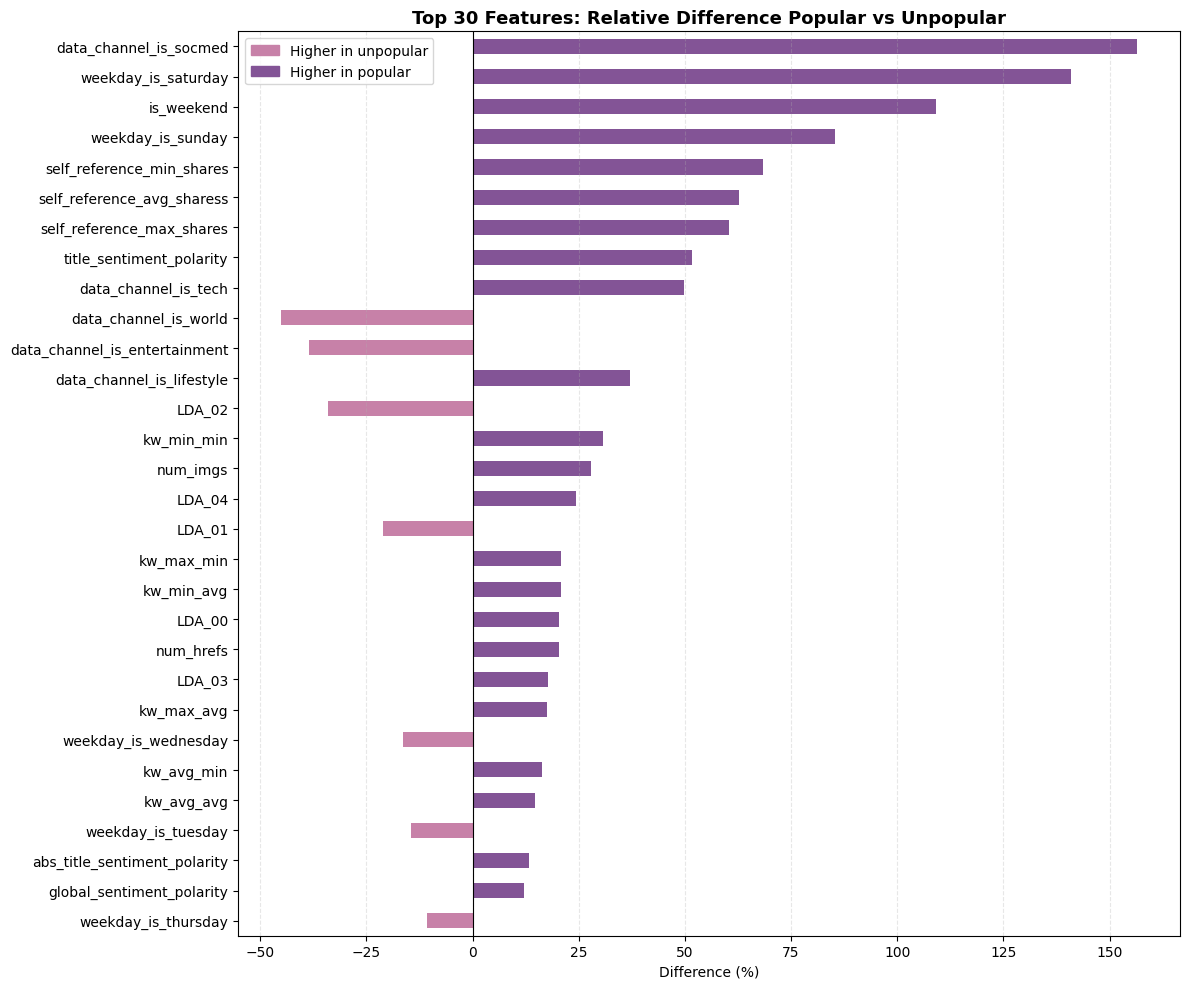

In [145]:
# COMPUTE FEATURE MEANS IN SPARK

# Identify numeric columns only (exclude categorical/text like URL)
numeric_cols = [f.name for f in sdf.schema.fields if isinstance(f.dataType, T.NumericType)]

# Remove target variable from feature list
for f in ['label', 'shares']:
    if f in numeric_cols:
        numeric_cols.remove(f)

# Build aggregation expressions: compute mean for each numeric feature
agg_exprs = [F.avg(col).alias(col) for col in numeric_cols]

# Group by class label and compute feature-wise averages
# Result: exactly 2 rows → label 0 and label 1
avg_df = sdf.groupBy('label').agg(*agg_exprs)

# Convert Spark result to Pandas for easier manipulation and plotting
pdf_avgs = avg_df.toPandas()

# PREPARE CLASS-LEVEL STATISTICS

# Extract mean feature values for each class
unpopular_mean = pdf_avgs[pdf_avgs['label'] == 0].drop(columns=['label']).iloc[0]
popular_mean = pdf_avgs[pdf_avgs['label'] == 1].drop(columns=['label']).iloc[0]

# COMPUTE RELATIVE DIFFERENCE (%)

# Create a comparison table: Each feature has a mean value for both classes
class_diff = pd.DataFrame({'Mean_Unpopular': unpopular_mean, 'Mean_Popular':   popular_mean})

# Relative percentage difference: (Popular - Unpopular) / Unpopular × 100
# Measures how much a feature increases/decreases in popularity class
class_diff['Diff (%)'] = ((class_diff['Mean_Popular'] - class_diff['Mean_Unpopular']) / class_diff['Mean_Unpopular'].replace(0, np.nan)) * 100
# Absolute difference used for ranking feature importance
class_diff['Abs_Diff'] = class_diff['Diff (%)'].abs()

# SELECT TOP DISCRIMINATIVE FEATURES

# Sort features by strongest class separation
top30_diff  = class_diff.sort_values('Abs_Diff', ascending=False).head(30)
# Color encoding
colors_diff = np.where(top30_diff['Diff (%)'] > 0, '#835496', '#C781A8')

# VISUALIZATION

plt.figure(figsize=(12, 10))
# Horizontal bar plot of percentage differences
top30_diff['Diff (%)'].plot(kind='barh', color=colors_diff)

plt.title('Top 30 Features: Relative Difference Popular vs Unpopular', fontsize=13, fontweight='bold')
plt.xlabel('Difference (%)')
# Reference line at zero (no difference)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.3)
# Invert y-axis so most important features appear at top
plt.gca().invert_yaxis()

# LEGEND
purple_patch = mpatches.Patch(color='#C781A8', label='Higher in unpopular')
pink_patch = mpatches.Patch(color='#835496', label='Higher in popular')
plt.legend(handles=[purple_patch, pink_patch])

plt.tight_layout()
plt.show()

## Feature Engineering & Preprocessing

58 numeric features are assembled into a single vector using 'VectorAssembler'.

**Important — Data Leakage Prevention:**  
'StandardScaler' (zero mean, unit variance) is fitted exclusively on the training window of each fold and then applied to both the training and test sets. Fitting on the full dataset or including test data in the scaler fit may cause data leakage of future information into the model.

In [146]:
# Define columns that should NOT be used as features
exclude_cols = ["url", "timedelta", "shares", "label"]
# Keep only feature columns for machine learning input
feature_cols = [col for col in sdf.columns if col not in exclude_cols]
# Print number of features used in the model
print(f"The number of feature = {len(feature_cols)}")

# Feature engineering (Vector Assembly)

# Combine all feature columns into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
# Apply transformation to create "features" column
assembled_sdf = assembler.transform(sdf)
# Keep only relevant columns for modeling
prepared_sdf = assembled_sdf.select("timedelta", "features", "label")

# Count the total number of samples
num_samples = prepared_sdf.count()
# Order dataset by time (newest first) -> is useful for time-aware splitting
sdf_ordered = prepared_sdf.orderBy(col("timedelta").desc())
# Cache dataset in memory to speed up repeated operations (avoids recomputation in future actions)
sdf_ordered.cache()

# Output results
print(f"The number of data: {num_samples}")
prepared_sdf.show(5)

The number of feature = 58
The number of data: 39644
+---------+--------------------+-----+
|timedelta|            features|label|
+---------+--------------------+-----+
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    1|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
+---------+--------------------+-----+
only showing top 5 rows


## Rolling Window 

Because news articles are published sequentially, a standard random train/test split would leak future information into training. Instead, we use **rolling window**, which respects the temporal order of the data.

Each fold slides the window forward by one step (`L`), so the model is always trained on past data and evaluated on truly unseen future data.

| Parameter | Value | Description |
|---|---|---|
| `train_size` (W) | 10,000 | Fixed window size (Train + Eval) |
| `step_size` (L) | 1,000 | Step size = test block size per fold |
| `train_frac` | 0.70 | 70% Train / 30% Eval within the window |
| Total folds | 29 | - |

In [147]:
# CONFIGURATION (rolling window setup)
@dataclass
class WindowConfig:
    train_size: int = 10_000     # Size of the sliding window (Train + Eval combined)
    step_size: int  = 1_000      # Step size: how much the window shifts each fold
    train_frac: float = 0.70     # Train/Validation split 70/30
    time_col: str = "timedelta"  # Column used for ordering
    row_col: str = "row_num"     # Column used for row indexing (0-based after ranking)
    reveal: bool = True          # Whether to print information

In [148]:
# PRINT CONFIGURATION DETAILS
def _print_config(cfg: WindowConfig, num_folds):

    # Split window into train and eval portions
    n_train = math.floor(cfg.train_frac * cfg.train_size)
    n_eval  = cfg.train_size - n_train
    
    print("Window Parameters")
    print(f"Fixed window size  : {cfg.train_size:,}  "f"(Train={n_train:,} + Eval={n_eval:,})")
    print(f"Step / Test size : {cfg.step_size:,}")
    print(f"Number of folds : {num_folds}")
    print(f"Train fraction : {cfg.train_frac:.0%}")
    print()


def _print_fold_table(records: list[dict]) -> None:
    """
    Prints a formatted summary table of all folds.

    Each fold shows:
    - Train / Eval / Test index ranges
    - Number of samples in each split
    """

    #helper function: Format a half-open interval [start, end) into a readable range
    def rng(start: int, end: int) -> str:
        """Return 'start – end-1', e.g.  '28,000 – 34,999'."""
        return f"{start:,} – {end - 1:,}"

    # Precompute string representations for width calculation
    tr_cells = [rng(r["tr_start"], r["tr_end"]) for r in records]
    ev_cells = [rng(r["ev_start"], r["ev_end"]) for r in records]
    te_cells = [rng(r["te_start"], r["te_end"]) for r in records]

    # Compute column widths dynamically for alignment
    w_fold   = max(4,  len(str(len(records))))          # "Fold"
    w_train  = max(5,  max(len(c) for c in tr_cells))  # "Train"
    w_eval   = max(4,  max(len(c) for c in ev_cells))  # "Eval"
    w_test   = max(4,  max(len(c) for c in te_cells))  # "Test"
    w_ntrain = max(7,  len(f"{records[-1]['n_train']:,}"))  # "n_train"
    w_neval  = max(6,  len(f"{records[-1]['n_eval']:,}"))   # "n_eval"
    w_ntest  = max(6,  len(f"{records[-1]['n_test']:,}"))   # "n_test"

    col_gap = "   "   # gap between every column
    
    # Header row
    header = (
        f"  {'Fold':>{w_fold}}{col_gap}"
        f"{'Train':>{w_train}}{col_gap}"
        f"{'Eval':>{w_eval}}{col_gap}"
        f"{'Test':>{w_test}}{col_gap}"
        f"{'n_train':>{w_ntrain}}{col_gap}"
        f"{'n_eval':>{w_neval}}{col_gap}"
        f"{'n_test':>{w_ntest}}"
    )
    separator = "  " + "─" * (len(header) - 2)

    print(header)
    print(separator)

    # Print each fold row
    for r, tr, ev, te in zip(records, tr_cells, ev_cells, te_cells):
        print(
            f"  {r['fold']:>{w_fold}}{col_gap}"
            f"{tr:>{w_train}}{col_gap}"
            f"{ev:>{w_eval}}{col_gap}"
            f"{te:>{w_test}}{col_gap}"
            f"{r['n_train']:>{w_ntrain},}{col_gap}"
            f"{r['n_eval']:>{w_neval},}{col_gap}"
            f"{r['n_test']:>{w_ntest},}"
        )
    print()

In [149]:
# MAIN WINDOW SPLITTING FUNCTION
def window_splitting(df, cfg : WindowConfig | None = None, **kwargs,):
    """
    Creates rolling window train/eval/test splits for time series.

    Key idea:
    - Fixed-size window (Train + Eval)
    - Sliding forward by step_size each fold
    - Separate test block following each window
    """
    
    # Use default config if none provided
    if cfg is None:
        cfg = WindowConfig(**kwargs)

    # 1. create time ordering
    window_spec = Window.orderBy(col(cfg.time_col).desc())
    # Assign sequential row numbers (0-based indexing)
    data = (df.withColumn(cfg.row_col, row_number().over(window_spec) - 1).cache()) # -1 converts 1-based → 0-based
    total_rows = data.count()

    # 2. compute window sizes
    W = cfg.train_size # window size (Train + Eval)
    L = cfg.step_size # test size / step size
    num_folds = (total_rows - W) // L
    # Split window into train and eval portions
    n_train = math.floor(cfg.train_frac * W) 
    n_eval  = W - n_train 
    
    # Print config if enabled
    if cfg.reveal == True :
        _print_config(cfg, num_folds)

    splits : list[tuple[DataFrame, DataFrame]] = []
    records : list[dict] = []   # for the printed table and the plot

    # 3. rolling window loop
    for fold in range(num_folds):

        # Define window boundaries
        win_start = fold * L            # first row of Train block
        ev_start = win_start + n_train  # first row of Eval block
        win_end = win_start + W         # one past last row of Eval (= te_start)
        te_start = win_end              # first row of Test block
        te_end = te_start + L           # one past last row of Test

        # Safety check: Stop if we exceed dataset bounds
        if te_end > total_rows:
            print(f"[WARNING] fold {fold+1} exceeds dataset size. Stopping early.")
            break

        # 4. slice data splits
        # Train + Eval combined (used for fitting scaler)
        full_train_raw = (data.filter((col(cfg.row_col) >= win_start) & (col(cfg.row_col) < win_end)).select("features", "label"))
        # Test set (future unseen data)
        test_raw = (data.filter((col(cfg.row_col) >= te_start) & (col(cfg.row_col) < te_end)).select("features", "label"))

        # 5. feature scaling
        # Fit scaler ONLY on training window (prevents data leakage)
        scaler = StandardScaler(inputCol  = "features", outputCol = "scaled_features", withMean = True, withStd = True)
        scaler_model = scaler.fit(full_train_raw)   # ← ONLY on Train

        # Transform training and test sets using the same scaler
        full_train_df = (scaler_model.transform(full_train_raw).select(col("scaled_features").alias("features"), "label"))
        test_df = (scaler_model.transform(test_raw).select(col("scaled_features").alias("features"), "label"))

        # Store split
        splits.append((full_train_df, test_df))

        # Store metadata
        records.append({
            "fold": fold + 1,
            "tr_start": win_start,
            "tr_end": ev_start,      
            "ev_start": ev_start,
            "ev_end": win_end,        
            "te_start": te_start,
            "te_end": te_end,         
            "n_train": n_train,
            "n_eval": n_eval,
            "n_test": L,
        })

    # Print fold summary table
    if cfg.reveal == True:
        _print_fold_table(records)

    return splits

In [150]:
# RUN CONFIGURATION
cfg = WindowConfig(
    train_size = 10_000,
    step_size = 1_000,
    train_frac = 0.70,
    time_col = "timedelta",
    reveal = True
    )

# Execute rolling window splitting
splits = window_splitting(sdf_ordered, cfg)

Window Parameters
Fixed window size  : 10,000  (Train=7,000 + Eval=3,000)
Step / Test size : 1,000
Number of folds : 29
Train fraction : 70%

  Fold             Train              Eval              Test   n_train   n_eval   n_test
  ──────────────────────────────────────────────────────────────────────────────────────
     1         0 – 6,999     7,000 – 9,999   10,000 – 10,999     7,000    3,000    1,000
     2     1,000 – 7,999    8,000 – 10,999   11,000 – 11,999     7,000    3,000    1,000
     3     2,000 – 8,999    9,000 – 11,999   12,000 – 12,999     7,000    3,000    1,000
     4     3,000 – 9,999   10,000 – 12,999   13,000 – 13,999     7,000    3,000    1,000
     5    4,000 – 10,999   11,000 – 13,999   14,000 – 14,999     7,000    3,000    1,000
     6    5,000 – 11,999   12,000 – 14,999   15,000 – 15,999     7,000    3,000    1,000
     7    6,000 – 12,999   13,000 – 15,999   16,000 – 16,999     7,000    3,000    1,000
     8    7,000 – 13,999   14,000 – 16,999   17,000 – 17,

## Model Definition & Hyperparameter Grids

Four classifiers are evaluated. Hyperparameters are tuned at each fold using "TrainValidationSplit" (70/30 split, optimising AUC).

| Model | Parameters Tuned | Grid Size |
|---|---|---|
| **Logistic Regression** | `regParam` ∈ {0.01, 0.1, 1.0}, `elasticNetParam` ∈ {0.0, 0.5, 1.0} | 9 |
| **Random Forest** | `numTrees` ∈ {10, 50, 100} | 3 |
| **Gradient Boosted Trees** | `maxDepth` ∈ {3, 5}, `maxIter` ∈ {50, 100} | 4 |
| **Linear SVM** | `regParam` ∈ {0.01, 0.1, 1.0}, `maxIter` ∈ {100, 200} | 6 | 

In [151]:
# Logistic Regression - 3 x 3 = 9 combinations
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

lr_grid = (
    ParamGridBuilder() 
    .addGrid(lr.regParam, [0.01, 0.1, 1.0]) 
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) 
    .build()
)

# Random Forest  — 3 combinations
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
)

rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [10, 50, 100])
    .build()
)


# Gradient Boosted Trees (GBT)  — 2 × 2 = 4 combinations
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
)

gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxIter, [50, 100])
    .build()
)

# # Linear Support Vector Machine (SVM) - 3 x 2 = 6 combinations
svm = LinearSVC(
    featuresCol="features",
    labelCol="label"
)

svm_grid = (
    ParamGridBuilder() 
    .addGrid(svm.regParam, [0.01, 0.1, 1.0]) 
    .addGrid(svm.maxIter, [100, 200]) 
    .build()
)

# Store all models and parameter grids
model_configs = [
    ("Logistic Regression", lr,  lr_grid),
    ("Random Forest", rf,  rf_grid),
    ("Gradient Boosted Tree", gbt, gbt_grid),
    ("Support Vector Machine", svm, svm_grid),
]

# Print number of hyperparameter combinations
print("Model configs ready.")
for name, _, grid in model_configs:
    print(f"{name}: {len(grid)} combinations")

Model configs ready.
Logistic Regression: 9 combinations
Random Forest: 3 combinations
Gradient Boosted Tree: 4 combinations
Support Vector Machine: 6 combinations


## Training Pipeline

### Helper Functions

- `compute_metrics` — evaluates a predictions DataFrame and returns AUC, Accuracy, F1, Precision, and Recall.  
- `train_algorithem` — The full rolling-window loop: for each fold, it tunes and trains every model, evaluates on the test block, and aggregates results across all windows.

In [152]:
# METRIC COMPUTATION
def compute_metrics(predictions):
    """
    Computes classification performance metrics.

    Metrics:
    - AUC (ROC Area Under Curve)
    - Accuracy
    - F1-score
    - Precision
    - Recall
    """
    
     # Binary evaluator for AUC
    auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC").evaluate(predictions)
    
    # Multiclass evaluator for standard metrics (Accuracy, F1, Precision, and Recall)
    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    
    accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
    f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
    precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
    recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
    
    return {
        "AUC": auc,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

In [153]:
# ROLLING WINDOW TRAINING
def train_algorithem(df, model_config, cfg: WindowConfig):

    # Print training start banner
    print(f"\n{'='*80}")
    print("Rolling window training")
    print(f"{'='*80}")
    
    # Storage dictionary for results
    results = {}

    # Initialize storage for each algorithm
    for model_name,_,_ in model_config:
        results[model_name] = {
            'metrics': [],
            'predictions': [],
            'best_params_per_window': []
        }
    
    # Compute number of folds/windows
    total_rows = df.count()
    num_folds = (total_rows - cfg.train_size) // cfg.step_size

    # Generate rolling window splits
    splits = window_splitting(df, cfg)

    # LOOP OVER TIME WINDOWS
    for fold in splits:
        print("\n" + "—" * 80)
        print(f"FOLD {splits.index(fold)+1}")
        print("—" * 80)

        # Current train and test split
        train = fold[0].cache()
        test = fold[1].cache()
        
        # LOOP OVER ALGORITHMS
        for model_name, model, param_grid in model_configs:
            print(f"\n[{model_name}] tuning ({len(param_grid)} combinations)...")
            
            # Hyperparameter tuning using TrainValidationSplit
            tvs = TrainValidationSplit(
                estimator = model,
                estimatorParamMaps = param_grid,
                # Optimize using AUC
                evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
                # Train/Validation split
                trainRatio = 0.7, # train/Val -> 70/30
                seed = 42,
                # Parallel execution
                parallelism = 8
            )
    
            # Fit tuning process on training window
            tvs_model = tvs.fit(train)
            
            # Extract best model and parameters 
            best_model = tvs_model.bestModel
            best_params = best_model.extractParamMap()
    
            # Convert parameter map to dictionary
            best_params_results = {param.name: value for param, value in best_params.items()}
    
            # Retrain model on full training window with best params
            final_model = model.copy(best_params)
            final_model = final_model.fit(train)
    
            # Predict on future test data
            predictions = final_model.transform(test)
    
            # Compute evaluation metrics
            metrics = compute_metrics(predictions)
    
            # Store predictions for ROC analysis
            # probability → LR/RF/GBT
            # rawPrediction → SVM
            if "probability" in predictions.columns:
                pred_df = predictions.select("label", "probability").toPandas()
            else:
                pred_df = predictions.select("label", "rawPrediction").toPandas()

            # Store results
            results[model_name]['metrics'].append(metrics)
            results[model_name]['predictions'].append(pred_df)
            results[model_name]['best_params_per_window'].append(best_params)

            # Print performance for current fold
            print(f"AUC: {metrics['AUC']:.4f} | "
                f"Accuracy={metrics['Accuracy']:.4f} | "
                f"F1={metrics['F1-Score']:.4f} | "
                f"Precision={metrics['Precision']:.4f} | "
                f"Rrcall={metrics['Recall']:.4f} | "
            )
        
        # Free memory after fold
        train.unpersist()
        test.unpersist()
    
    # COMPUTE FINAL AVERAGES
    final_results = {}
    
    for model_name in results.keys():
        all_metrics = results[model_name]['metrics']
        
        # Average metrics across windows
        avg_metrics = {}
        
        for metric_name in all_metrics[0].keys():
            avg_metrics[metric_name] = np.mean([m[metric_name] for m in all_metrics])
        
        final_results[model_name] = {
            'avg_metrics': avg_metrics,
            'all_metrics': results[model_name]['metrics'],
            'all_predictions': results[model_name]['predictions'],
            'best_params_per_window': results[model_name]['best_params_per_window']
        }

        # Print final average performance
        print(f"{model_name} - Average Performance on test set across {num_folds} windows:")
        print(f"AUC: {avg_metrics['AUC']:.4f}")
        print(f"Accuracy: {avg_metrics['Accuracy']:.4f}")
        print(f"F1-Score: {avg_metrics['F1-Score']:.4f}")
        print(f"Precision: {avg_metrics['Precision']:.4f}")
        print(f"Recall: {avg_metrics['Recall']:.4f}\n")
    
    return final_results

In [154]:
# TRAIN ALL ALGORITHMS
cfg = WindowConfig(
    train_size = 10_000,
    step_size = 1_000,
    train_frac = 0.70,
    time_col = "timedelta",
    reveal = False
    )

final_results = train_algorithem(sdf_ordered, model_configs, cfg)


Rolling window training

————————————————————————————————————————————————————————————————————————————————
FOLD 1
————————————————————————————————————————————————————————————————————————————————

[Logistic Regression] tuning (9 combinations)...
AUC: 0.6838 | Accuracy=0.6360 | F1=0.6377 | Precision=0.6409 | Rrcall=0.6360 | 

[Random Forest] tuning (3 combinations)...
AUC: 0.6880 | Accuracy=0.6310 | F1=0.6332 | Precision=0.6488 | Rrcall=0.6310 | 

[Gradient Boosted Tree] tuning (4 combinations)...
AUC: 0.6764 | Accuracy=0.6390 | F1=0.6296 | Precision=0.6322 | Rrcall=0.6390 | 

[Support Vector Machine] tuning (6 combinations)...
AUC: 0.6758 | Accuracy=0.6250 | F1=0.6268 | Precision=0.6465 | Rrcall=0.6250 | 

————————————————————————————————————————————————————————————————————————————————
FOLD 2
————————————————————————————————————————————————————————————————————————————————

[Logistic Regression] tuning (9 combinations)...
AUC: 0.7124 | Accuracy=0.6730 | F1=0.6732 | Precision=0.6733 | Rrc

## Final Results & Evaluation

This section visualises the complete evaluation of all four models across all rolling windows:

1. Summary table: average metrics (AUC, Accuracy, F1, Precision, Recall) for every model 
2. ROC curves: averaged across all windows per model  
3. Metrics over time: AUC, Accuracy, and F1-Score per fold for every model  
4. Feature importance: top-30 features ranked by the best-performing model

In [155]:
# Colour palette
PALETTE = {
    "Logistic Regression":     "#835496",
    "Random Forest":           "#C781A8",
    "Gradient Boosted Tree":   "#5B8DB8",
    "Support Vector Machine": "#6BAE75",
}
MODEL_NAMES = list(PALETTE.keys())

### Summary Table — Average Metrics Across All Windows

The table below reports each model's mean performance averaged over all 29 test folds.

In [156]:
# BUILD FINAL SUMMARY TABLE

# Create an empty list to store one row per model
rows = []

# Iterate over all trained models
for model_name in MODEL_NAMES:
    
    # Extract average metrics computed across all rolling windows
    avg = final_results[model_name]['avg_metrics']

    # Store results in dictionary format (one row per model)
    rows.append({
        "Model": model_name.strip(),
        "AUC": avg["AUC"],
        "Accuracy": avg["Accuracy"],
        "F1-Score": avg["F1-Score"],
        "Precision": avg["Precision"],
        "Recall": avg["Recall"],
    })

# Convert list of dictionaries into a Pandas DataFrame
summary_df = pd.DataFrame(rows).set_index("Model")
print(summary_df.to_string())

print("\nBest model per metric:")
for col in summary_df.columns:
    best = summary_df[col].idxmax()
    print(f"  {col:12s}: {best}  ({summary_df.loc[best, col]:.4f})")

                             AUC  Accuracy  F1-Score  Precision    Recall
Model                                                                    
Logistic Regression     0.708038  0.655690  0.654468   0.659649  0.655690
Random Forest           0.714497  0.659276  0.658670   0.663437  0.659276
Gradient Boosted Tree   0.721843  0.665207  0.664105   0.666469  0.665207
Support Vector Machine  0.707126  0.653207  0.652088   0.658951  0.653207

Best model per metric:
  AUC         : Gradient Boosted Tree  (0.7218)
  Accuracy    : Gradient Boosted Tree  (0.6652)
  F1-Score    : Gradient Boosted Tree  (0.6641)
  Precision   : Gradient Boosted Tree  (0.6665)
  Recall      : Gradient Boosted Tree  (0.6652)


### 2 · ROC Curves — Averaged Across All Windows

Each model's ROC curve is computed for every rolling window and then averaged across folds.

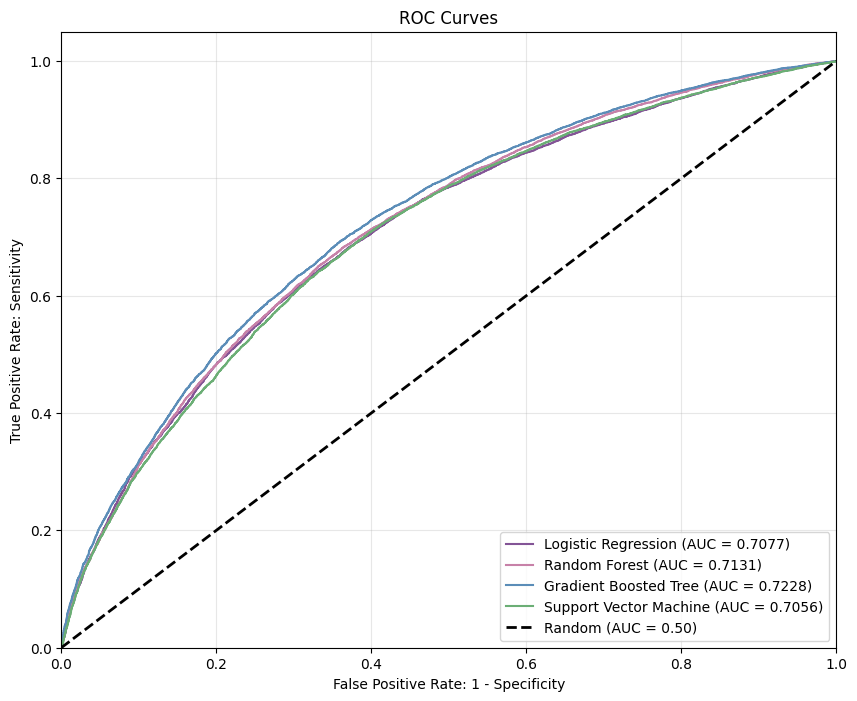

In [157]:
# Plot ROC Curves for all algorithms
plt.figure(figsize=(10, 8))

for model_name in MODEL_NAMES:
    color = PALETTE[model_name]
    # All predictions across rolling windows
    all_preds = final_results[model_name]['all_predictions']
    
    labels, scores = [], []
    
    for pred_df in all_preds:
        labels.extend(pred_df['label'].values)
        
        # Extract probability for class 1
        if 'probability' in pred_df.columns:
             scores.extend([row[1] for row in pred_df['probability']])
        elif 'rawPrediction' in pred_df.columns:
             scores.extend([row[1] for row in pred_df['rawPrediction']])

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, color=color, label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate: 1 - Specificity')
plt.ylabel('True Positive Rate: Sensitivity')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### AUC, Accuracy & F1-Score Over Rolling Windows

The plots below track each metric across consecutive folds. Trends reveal the model's performance as the data window shifts forward in time.

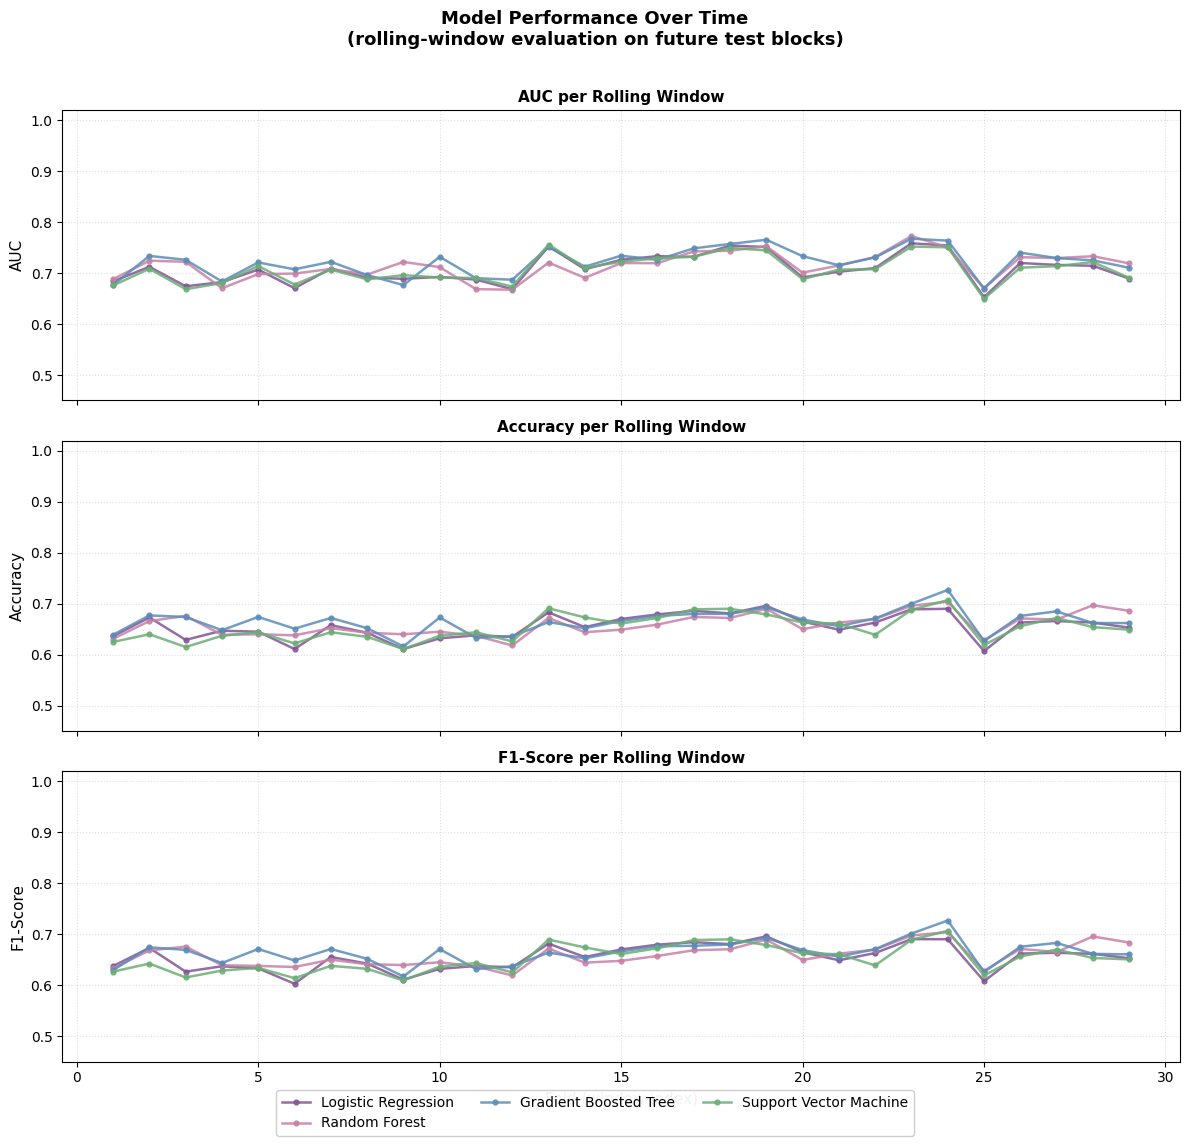

In [158]:
# METRICS VISUALIZATION OVER TIME

# Metrics to visualize across rolling windows
metrics_to_plot = ["AUC", "Accuracy", "F1-Score"]

# Create a vertical subplot layout (one plot per metric)
# sharex=True → all plots share the same x-axis (fold index)
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

# PLOT EACH METRIC
for ax, metric in zip(axes, metrics_to_plot):

    # Plot each model on the same axis
    for model_name in MODEL_NAMES:
        
        color = PALETTE[model_name]
        # Extract metric values across all rolling windows (folds)
        values = [m[metric] for m in final_results[model_name]['all_metrics']]
        # Fold index (1-based for readability)
        folds  = list(range(1, len(values) + 1))
        # Line plot: performance over time
        ax.plot(folds, values, marker="o", markersize=3.5, linewidth=1.8, color=color, label=model_name.strip(), alpha=0.85)
    
    # Axis formatting
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{metric} per Rolling Window", fontsize=11, fontweight="bold")
    ax.grid(axis="both", linestyle=":", alpha=0.4)
    ax.set_facecolor("white")
    ax.set_ylim(0.45, 1.02)

# GLOBAL FIGURE SETTINGS
# X-axis label shared across all plots
axes[-1].set_xlabel("Fold (window index)", fontsize=11)
# Extract legend handles from first subplot
handles, labels = axes[0].get_legend_handles_labels()
# Place a single legend at the bottom center of the figure
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=10, framealpha=0.95, bbox_to_anchor=(0.5, -0.02))

# Global title for the figure
fig.suptitle("Model Performance Over Time\n(rolling-window evaluation on future test blocks)", fontsize=13, fontweight="bold", y=1.01)
# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()